# Time-Resolved Spectral Analysis of Single-Pulse GRBs — Worked Example

**Purpose.** This notebook walks through the full per-burst analysis used in the
Two_Breaks project, end-to-end, on one representative burst (**GRB 110721A**,
`bn110721200` — the Burgess+2013 blackbody-demonstration burst). It is meant for
review: every step is shown and runnable.

**The science question.** Is the curvature in a GRB prompt spectrum a *thermal*
(photosphere / blackbody) component on top of a non-thermal continuum
(Burgess+2014), or a *second synchrotron break* (2SBPL, with cooling \(\nu_c\)
and injection \(\nu_m=E_p\))? We fit **both** families per time bin and let the
data decide.

**What the notebook does**
1. Loads the burst, light curve, and the Bayesian-block time bins.
2. Describes the **six** spectral models we fit.
3. **Live-fits all six models** to the time-integrated spectrum (real 3ML engine).
4. Builds the **per-bin model-comparison table** (AIC / BIC / likelihood-ratio
   tests / physical-validity gate / best model).
5. Plots **parameter evolution** — \(E_p(t)\), \(kT(t)\), low-energy index
   \(\alpha(t)\), break energies.
6. Plots the per-burst **\(E_p\)–\(kT\) correlation** (thermal vs non-thermal).

> The heavy fitting was done with `scripts/10_spectral_fit_burst.py`; results are
> stored in `results/.../spectral_fits.ecsv`. The analysis/plot cells read those
> saved results, so they run with only numpy/astropy/matplotlib/scipy. The single
> **live-fit** cell uses the 3ML environment (and falls back to saved values if
> 3ML is unavailable).


In [1]:
%matplotlib inline
# --- Setup: paths, the burst to analyse, and saved results ---
import os, sys, glob, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# locate the project root (the dir containing 'results' and 'scripts')
BASE = os.getcwd()
while BASE != '/' and not (os.path.isdir(os.path.join(BASE, 'results'))
                           and os.path.isdir(os.path.join(BASE, 'scripts'))):
    BASE = os.path.dirname(BASE)
print('project root:', BASE)

BURST   = 'bn110721200'                       # GRB 110721A
RESDIR  = os.path.join(BASE, 'results', 'burgess_repro', 'clean_per_burst', BURST)
if not os.path.exists(os.path.join(RESDIR, 'spectral_fits.ecsv')):
    RESDIR = os.path.join(BASE, 'results', 'clean_per_burst', BURST)   # fallback
DATA    = os.path.join(BASE, 'data', BURST)

res = Table.read(os.path.join(RESDIR, 'spectral_fits.ecsv'), format='ascii.ecsv')
res.sort('BLOCK')
tint   = res[res['BLOCK'] == -1]                 # time-integrated row
blocks = res[res['BLOCK'] >= 0]                  # per-time-bin rows
print(f'{BURST}: {len(blocks)} time bins + {len(tint)} time-integrated row')
print('models fit per bin: Band, CPL, SBPL, DSBPL, Band+BB, CPL+BB')
MODELS = ['BAND', 'CPL', 'SBPL', 'DSBPL', 'BANDBB', 'CPLBB']
LABEL  = {'BAND':'Band','CPL':'CPL','SBPL':'SBPL','DSBPL':'DSBPL(2SBPL)',
          'BANDBB':'Band+BB','CPLBB':'CPL+BB'}

project root: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks
bn110721200: 13 time bins + 1 time-integrated row
models fit per bin: Band, CPL, SBPL, DSBPL, Band+BB, CPL+BB


## 1. The burst and its time bins

We use the **reference NaI detector** (the GBM-catalog-selected NaI that defines the time bins; read from `single_pulse_grbs.ecsv`) and its count light curve (8–900 keV) and the
**Bayesian-block** time bins. Each block becomes one spectral fit, so bins are
fine where the spectrum evolves fast and coarse where it is steady. The dotted
lines below are the block edges that the spectral fits use.

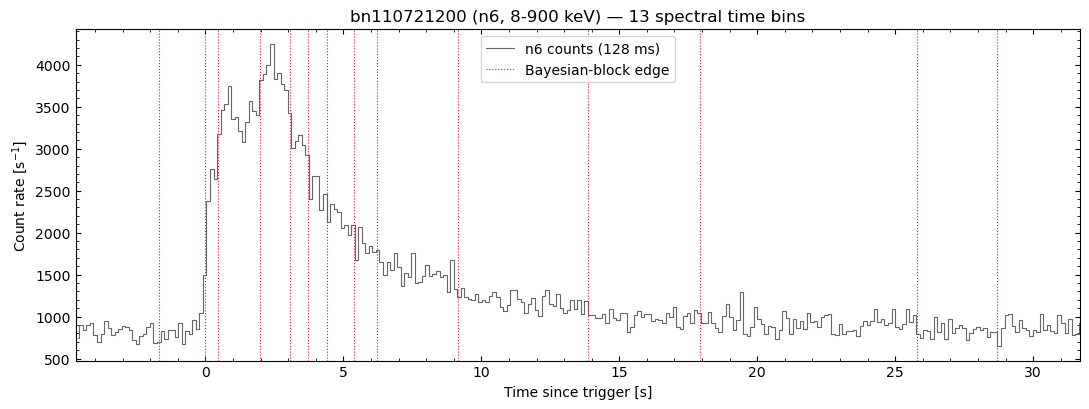

In [2]:
%matplotlib inline
# --- Light curve (brightest NaI, 8-900 keV) with the Bayesian-block edges ---
det_guess = None
sp_path = os.path.join(BASE, 'results', 'single_pulse_grbs.ecsv')
if os.path.exists(sp_path):
    sp = Table.read(sp_path, format='ascii.ecsv')
    m = sp['TRIGGER_NAME'] == BURST
    if m.any():
        det_guess = str(sp[m][0]['DETECTOR']).strip()
if not det_guess:
    raise RuntimeError(
        'Reference detector unknown: results/single_pulse_grbs.ecsv not found, '
        f'or {BURST} missing from it. Copy that file from the project results/ '
        'directory -- the notebook must NOT fall back to an arbitrary detector.')
det = det_guess

tte = sorted(glob.glob(os.path.join(DATA, f'glg_tte_{det}_*.fit*')))[0]
with fits.open(tte) as h:
    ev = h['EVENTS'].data
    t0 = next(hh.header['TRIGTIME'] for hh in h if 'TRIGTIME' in hh.header)
    eb = h['EBOUNDS'].data
    emid = 0.5*(np.asarray(eb['E_MIN'])+np.asarray(eb['E_MAX']))
    tt = np.asarray(ev['TIME']) - t0
    tt = tt[(emid[ev['PHA']] >= 8) & (emid[ev['PHA']] <= 900)]

lo = float(blocks['T_START'].min()) - 3
hi = float(blocks['T_STOP'].max()) + 3
bw = 0.128
edges = np.arange(lo, hi+bw, bw); ctr = 0.5*(edges[:-1]+edges[1:])
cnt, _ = np.histogram(tt, bins=edges)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.step(ctr, cnt/bw, where='mid', color='0.4', lw=0.8, label=f'{det} counts (128 ms)')
for i, r in enumerate(blocks):
    ax.axvline(float(r['T_START']), color='crimson', ls=':', lw=0.8,
               label='Bayesian-block edge' if i == 0 else None)
ax.axvline(float(blocks['T_STOP'].max()), color='crimson', ls=':', lw=0.8)
ax.set_xlim(lo, hi); ax.set_xlabel('Time since trigger [s]')
ax.set_ylabel('Count rate [s$^{-1}$]')
ax.set_title(f'{BURST} ({det}, 8-900 keV) — {len(blocks)} spectral time bins')
ax.legend(); ax.tick_params(direction='in', which='both', top=True, right=True)
ax.minorticks_on(); plt.tight_layout(); plt.show()

## 2. The six spectral models

All are forward-folded through the detector response and fit by maximum
likelihood (pgstat = Poisson source + Gaussian background) in **3ML**.

| Model | Parameters | Physical picture |
|---|---|---|
| **Band** | \(\alpha,\ \beta,\ E_p\) | empirical; the standard GRB function |
| **CPL** (cutoff PL) | index, \(E_c\) | empirical; \(E_p=(2+\mathrm{index})E_c\) |
| **SBPL** | \(\alpha,\ \beta,\ E_b\) | one smooth break |
| **DSBPL (2SBPL)** | \(\alpha_1,\alpha_2,\beta,\ x_b,\ x_p\) | **two** breaks → synchrotron \(\nu_c,\nu_m\) |
| **Band+BB** | Band \(+\ kT\) | non-thermal **+ thermal photosphere** |
| **CPL+BB** | CPL \(+\ kT\) | non-thermal **+ thermal photosphere** |

The two `+BB` models and the DSBPL are the competing explanations for *curvature
beyond a single break*: a **thermal bump** vs a **second synchrotron break**.
`Band+BB` / `CPL+BB` act as a practical proxy for `2SBPL`.

## 3. Live fit — all six models on the time-integrated spectrum

This cell runs the **actual production engine** (`scripts/10_spectral_fit_burst.py`):
it builds the time-integrated SpectrumLike for the brightest NaI and fits all six
models, reporting \(-2\ln L\), AIC, BIC and key parameters. If the 3ML environment
is not available it falls back to the saved time-integrated values.

In [3]:
# --- LIVE FIT: all 6 models on T_INT (real engine), with saved-value fallback ---
REFIT = True   # set False to skip live fitting and use saved results
import io, contextlib, importlib.util
live_rows = None
t0i, t1i = float(tint['T_START'][0]), float(tint['T_STOP'][0])

if REFIT:
    _log = io.StringIO()    # swallow 3ML's verbose logging + tqdm progress bars
    try:
        with contextlib.redirect_stdout(_log), contextlib.redirect_stderr(_log):
            spec = importlib.util.spec_from_file_location(
                's10', os.path.join(BASE, 'scripts', '10_spectral_fit_burst.py'))
            s10 = importlib.util.module_from_spec(spec); spec.loader.exec_module(s10)
            from threeML import DataList
            try:
                from threeML import update_logging_level; update_logging_level('FATAL')
            except Exception:
                pass
            # background windows for the brightest NaI
            bkg = Table.read(os.path.join(BASE, 'results',
                             'background_intervals_clean.ecsv'), format='ascii.ecsv')
            bk = bkg[(bkg['TRIGGER_NAME'] == BURST) & (bkg['DETECTOR'] == det)][0]
            pre  = (float(bk['BKG_NEG_START']), float(bk['BKG_NEG_STOP']))
            post = (float(bk['BKG_POS_START']), float(bk['BKG_POS_STOP']))
            plugins = s10.build_spectrumlike_per_block(BURST, det, pre, post, [t0i], [t1i])
            plugin = plugins[0]
            dl = DataList(plugin)
            # The +BB models have a railing local minimum (kT->1, BB->0, or a far
            # worse basin). The production engine (fit_all_models) guards this with
            # a BB MULTI-START: re-fit from a grid of hot kT seeds, keep the lowest
            # -2lnL. We replicate that here so the live demo matches production.
            BB_SEEDS = [{}, {'bb_kT': 30.0, 'bb_K': 1e-3}, {'bb_kT': 80.0, 'bb_K': 1e-3}]
            live_rows = []
            for spc in s10.MODEL_SPECS:
                r = s10.fit_one_model(dl, spc)
                if spc['name'] in ('Band+BB', 'CPL+BB'):
                    for extra in BB_SEEDS:
                        alt = s10.fit_one_model(dl, spc, seed=extra)
                        if (alt.get('status') == 'OK' and np.isfinite(alt['neg2logL'])
                                and alt['neg2logL'] < r['neg2logL'] - 1e-3):
                            r = alt
                n2 = r['neg2logL']; k = spc['n_params']
                live_rows.append((spc['name'], r.get('status'), n2,
                                  n2 + 2*k, n2 + k*np.log(max(plugin.n_data_points, 1))))
        print('LIVE FIT OK — all six models fit to T_INT spectrum '
              '(3ML log suppressed; set REFIT=False to use saved values)')
    except Exception as e:
        print('Live fit unavailable (', type(e).__name__, str(e)[:80], ') — using saved values')
        live_rows = None

# Build a tidy comparison table (live if available, else saved T_INT)
print(f'\n{"model":12s} {"-2lnL":>10s} {"AIC":>10s} {"BIC":>10s}')
if live_rows is not None:
    aic = {n: a for n, _, _, a, _ in live_rows}
    for n, st, n2, a, b in live_rows:
        print(f'{n:12s} {n2:>10.1f} {a:>10.1f} {b:>10.1f}')
    best = min(live_rows, key=lambda x: x[3])[0]
else:
    aic = {m: float(tint[f'{m}_AIC'][0]) for m in MODELS}
    for m in MODELS:
        print(f'{LABEL[m]:12s} {"-":>10s} {tint[m+"_AIC"][0]:>10.1f} {tint[m+"_BIC"][0]:>10.1f}')
    best = min(MODELS, key=lambda m: float(tint[f'{m}_AIC'][0]))
print(f'\nbest (lowest AIC) on T_INT: {best}')

08:52:47 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=885012;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=137604;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=731892;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=463506;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=713713;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=939656;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

08:52:48 INFO      Starting 3ML!                                                                     ]8;id=424774;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=508612;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=603881;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=691331;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/threeML/__init__.py#45\45]8;;\

...

08:52:50 WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=196819;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=76303;file:///Users/salim/anaconda3/envs/threeml/lib/python3.9/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

Finding best polynomial Order:   0%|          | 0/4 [00:00<?, ?it/s]

Fitting GBM_NAI_06 background:   0%|          | 0/128 [00:00<?, ?it/s]

Creating plugins:   0%|          | 0/1 [00:00<?, ?it/s]

LIVE FIT OK — all six models fit to T_INT spectrum (3ML log suppressed; set REFIT=False to use saved values)

model             -2lnL        AIC        BIC
Band             1690.5     1698.5     1709.6
CPL              1695.0     1701.0     1709.3
SBPL             1690.9     1698.9     1710.0
DSBPL            1691.0     1703.0     1719.7
Band+BB          1692.5     1704.5     1721.1
CPL+BB           1695.0     1705.0     1718.9

best (lowest AIC) on T_INT: Band


## 4. Model comparison per time bin

For every bin we compare the six models with:
- **AIC / BIC** (lower is better); we report \(\Delta\)AIC relative to the best.
- **Likelihood-ratio tests** for the *nested* pairs (Wilks):
  `Band+BB vs Band`, `CPL+BB vs CPL`, and `DSBPL vs SBPL`.
  An LRT \(\gtrsim 9.2\) (2 d.o.f.) is the blackbody / second-break detected at \(\sim\)99%.
- A **physical-validity gate**: a fit can only *win* if no key parameter is
  railed against a bound and (for DSBPL) the breaks are ordered \(x_b<x_p\).

In [4]:
# --- Per-bin model-comparison table from saved results ---
def fmt(x, d=1):
    return '—' if (x is None or not np.isfinite(x)) else f'{x:.{d}f}'

hdr = (f'{"bin":>3s} {"t0":>6s} {"t1":>6s} | ' +
       ' '.join(f'{LABEL[m][:6]:>7s}' for m in MODELS) +
       f' | {"best":>11s} {"LRT_BB":>7s} {"LRT_2brk":>8s}')
print(hdr); print('-'*len(hdr))
for r in blocks:
    aics = {m: float(r[f'{m}_AIC']) for m in MODELS}
    amin = min(v for v in aics.values() if np.isfinite(v))
    cells_ = ' '.join(f'{(aics[m]-amin):>7.1f}' if np.isfinite(aics[m]) else f'{"—":>7s}'
                      for m in MODELS)
    # LRT: best of the two +BB detections; second-break = DSBPL vs SBPL
    lrt_bb = max(float(r['LRT_BANDBB_BAND']) if np.isfinite(r['LRT_BANDBB_BAND']) else -9,
                 float(r['LRT_CPLBB_CPL'])   if np.isfinite(r['LRT_CPLBB_CPL'])   else -9)
    lrt_2b = float(r['LRT_DSBPL_SBPL']) if np.isfinite(r['LRT_DSBPL_SBPL']) else np.nan
    print(f'{r["BLOCK"]:>3d} {r["T_START"]:>6.2f} {r["T_STOP"]:>6.2f} | {cells_} | '
          f'{str(r["BEST_AIC_MODEL"]):>11s} {fmt(lrt_bb):>7s} {fmt(lrt_2b):>8s}')
print('\nColumns under each model = ΔAIC vs the best model in that bin (0 = winner).')
print('LRT_BB ≳ 9.2 → blackbody detected; LRT_2brk ≳ 9.2 → second break (2SBPL) preferred over SBPL.')

bin     t0     t1 |    Band     CPL    SBPL  DSBPL(  Band+B  CPL+BB |        best  LRT_BB LRT_2brk
--------------------------------------------------------------------------------------------------
  0  -1.70  -0.00 |     9.4     0.0     2.7    29.8     7.3     0.5 |         CPL     6.0    -23.1
  1  -0.00   0.44 |     0.2    65.6     0.0     2.2     3.4    40.8 |        SBPL    28.9      1.8
  2   0.44   1.98 |    81.4   257.0    85.4     9.1     0.0   114.3 |     Band+BB   146.7     80.3
  3   1.98   3.07 |    42.7   135.8    21.8     0.0    46.7    25.0 |       DSBPL   114.8     25.8
  4   3.07   3.71 |    12.7    26.3     7.0     0.0     5.1     7.8 |       DSBPL    22.5     11.0
  5   3.71   4.41 |     3.1    10.6     1.6     0.0     7.1     7.3 |       DSBPL     7.3      5.6
  6   4.41   5.37 |     0.8     0.0     0.8     0.8     2.0     2.3 |         CPL     2.9      4.1
  7   5.37   6.20 |     0.0     0.4     0.0     2.9     4.0     4.4 |        Band     0.0      1.1
  8   6.20

In [5]:
# --- Summary: how often each model wins, and the curvature split ---
from collections import Counter
win = Counter(str(r['BEST_AIC_MODEL']) for r in blocks)
print('Best-AIC model frequency across bins:')
for m, c in win.most_common():
    print(f'  {m:14s} {c:>3d}  ' + '#'*c)

# Curvature classification per bin: does it need >1 break, and if so thermal or 2-break?
n_curv = n_therm = n_2brk = n_degen = 0
for r in blocks:
    aics = {m: float(r[f'{m}_AIC']) for m in MODELS}
    best_single = min(aics['BAND'], aics['CPL'], aics['SBPL'])
    therm = min(aics['BANDBB'], aics['CPLBB'])
    twob  = aics['DSBPL']
    if min(therm, twob) < best_single - 6:                 # curvature beyond single break
        n_curv += 1
        if abs(therm - twob) <= 6:  n_degen += 1
        elif therm < twob:          n_therm += 1
        else:                       n_2brk  += 1
print(f'\nBins needing curvature beyond a single break (ΔAIC>6): {n_curv}/{len(blocks)}')
print(f'  thermal-proxy preferred : {n_therm}')
print(f'  two-break preferred     : {n_2brk}')
print(f'  degenerate (≈ equal)    : {n_degen}')

Best-AIC model frequency across bins:
  CPL              3  ###
  SBPL             3  ###
  DSBPL            3  ###
  Band             3  ###
  Band+BB          1  #

Bins needing curvature beyond a single break (ΔAIC>6): 3/13
  thermal-proxy preferred : 1
  two-break preferred     : 1
  degenerate (≈ equal)    : 1


## 5. Parameter evolution

Time evolution of the key physical parameters across the bins. For the
thermal+non-thermal picture we track the non-thermal peak \(E_p\) and the
blackbody temperature \(kT\); the low-energy index \(\alpha\) tests the
synchrotron expectation (\(\alpha\simeq-2/3\) slow-cooled, \(-3/2\) fast-cooled).

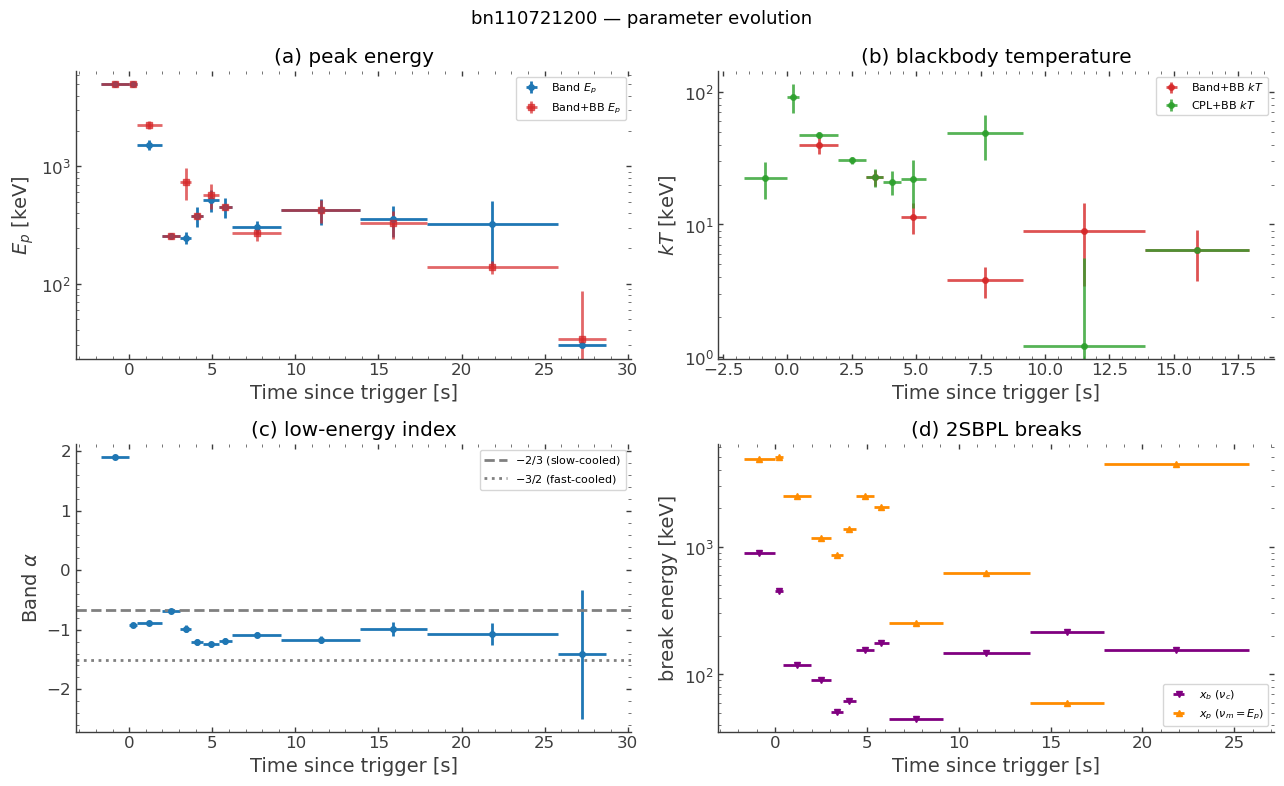

In [6]:
%matplotlib inline
# --- Parameter evolution plots ---
tc = 0.5*(np.asarray(blocks['T_START'], float) + np.asarray(blocks['T_STOP'], float))
tw = 0.5*(np.asarray(blocks['T_STOP'], float) - np.asarray(blocks['T_START'], float))

def col(name):
    return np.asarray(blocks[name], float) if name in blocks.colnames else np.full(len(blocks), np.nan)

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
# (a) Ep from Band and Band+BB
ax[0,0].errorbar(tc, col('BAND_EP'), xerr=tw, yerr=col('BAND_EP_ERR'),
                 fmt='o', ms=4, label='Band $E_p$', color='#1f77b4')
ax[0,0].errorbar(tc, col('BANDBB_EP'), xerr=tw, yerr=col('BANDBB_EP_ERR'),
                 fmt='s', ms=4, label='Band+BB $E_p$', color='#d62728', alpha=0.7)
ax[0,0].set_yscale('log'); ax[0,0].set_ylabel('$E_p$ [keV]'); ax[0,0].set_title('(a) peak energy')
# (b) kT from the two +BB models (only where BB is valid)
for c, lab, cc in [('BANDBB','Band+BB','#d62728'), ('CPLBB','CPL+BB','#2ca02c')]:
    kt = col(f'{c}_KT'); valid = np.asarray(blocks[f'{c}_VALID'], bool) if f'{c}_VALID' in blocks.colnames else np.isfinite(kt)
    ax[0,1].errorbar(tc[valid], kt[valid], xerr=tw[valid], yerr=col(f'{c}_KT_ERR')[valid],
                     fmt='o', ms=4, label=f'{lab} $kT$', color=cc, alpha=0.8)
ax[0,1].set_yscale('log'); ax[0,1].set_ylabel('$kT$ [keV]'); ax[0,1].set_title('(b) blackbody temperature')
# (c) low-energy index alpha (Band) with synchrotron reference lines
ax[1,0].errorbar(tc, col('BAND_ALPHA'), xerr=tw, yerr=col('BAND_ALPHA_ERR'),
                 fmt='o', ms=4, color='#1f77b4')
ax[1,0].axhline(-2/3, ls='--', color='0.5', label=r'$-2/3$ (slow-cooled)')
ax[1,0].axhline(-3/2, ls=':',  color='0.5', label=r'$-3/2$ (fast-cooled)')
ax[1,0].set_ylabel(r'Band $\alpha$'); ax[1,0].set_title('(c) low-energy index')
# (d) DSBPL break energies (the 2SBPL two breaks)
ax[1,1].errorbar(tc, col('DSBPL_XB'), xerr=tw, fmt='v', ms=4, label=r'$x_b$ ($\nu_c$)', color='purple')
ax[1,1].errorbar(tc, col('DSBPL_XP'), xerr=tw, fmt='^', ms=4, label=r'$x_p$ ($\nu_m=E_p$)', color='darkorange')
ax[1,1].set_yscale('log'); ax[1,1].set_ylabel('break energy [keV]'); ax[1,1].set_title('(d) 2SBPL breaks')
for a in ax.flat:
    a.set_xlabel('Time since trigger [s]'); a.legend(fontsize=8)
    a.tick_params(direction='in', which='both', top=True, right=True); a.minorticks_on()
fig.suptitle(f'{BURST} — parameter evolution', fontsize=13)
plt.tight_layout(); plt.show()

## 6. The \(E_p\)–\(kT\) correlation (thermal vs non-thermal)

Burgess+2014 found a tight per-burst relation \(E_p\propto kT^{\alpha}\): slope
\(\alpha\!\approx\!1\) (baryonic jet) to \(\alpha\!\approx\!2\) (magnetic). We
take the bins where the blackbody is genuinely detected (LRT \(>9.2\)), with
\(E_p\) the \(\nu F_\nu\) peak of the chosen model (`Band+BB` → \(x_p\);
`CPL+BB` → \((2+\mathrm{index})\,E_c\)).

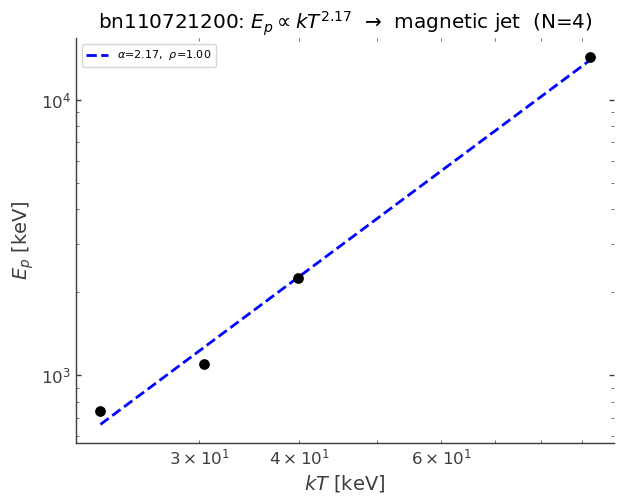

BB-significant bins (LRT>9.2): N=4


In [7]:
%matplotlib inline
# --- Per-burst Ep-kT correlation (BB-significant bins) ---
from scipy.stats import spearmanr
EPB=(30,5000); KTB=(1,200); LRT_MIN=9.2
def cpl_peak(i, xc): return (2+i)*xc if i > -2 else np.nan
kt_l, ep_l = [], []
for r in blocks:
    cands = []
    if bool(r.get('BANDBB_VALID', False)):
        l = float(r['LRT_BANDBB_BAND']); kt=float(r['BANDBB_KT']); ep=float(r['BANDBB_EP'])
        rail = kt<=KTB[0]*1.02 or kt>=KTB[1]*0.98 or ep<=EPB[0]*1.02
        if np.isfinite(l) and l>=LRT_MIN and not rail and ep>0:
            cands.append((float(r['BANDBB_AIC']), kt, ep))
    if bool(r.get('CPLBB_VALID', False)):
        l=float(r['LRT_CPLBB_CPL']); kt=float(r['CPLBB_KT']); ep=cpl_peak(float(r['CPLBB_INDEX']), float(r['CPLBB_XC']))
        rail = kt<=KTB[0]*1.02 or kt>=KTB[1]*0.98
        if np.isfinite(l) and l>=LRT_MIN and not rail and np.isfinite(ep) and ep>0:
            cands.append((float(r['CPLBB_AIC']), kt, ep))
    if cands:
        cands.sort(); kt_l.append(cands[0][1]); ep_l.append(cands[0][2])
kt_a, ep_a = np.array(kt_l), np.array(ep_l)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
if len(kt_a) >= 1:
    ax.scatter(kt_a, ep_a, c='k', s=45, zorder=3)
if len(kt_a) >= 3:
    c = np.polyfit(np.log10(kt_a), np.log10(ep_a), 1)
    rho, p = spearmanr(kt_a, ep_a)
    xx = np.logspace(np.log10(kt_a.min()), np.log10(kt_a.max()), 30)
    ax.plot(xx, 10**(c[1]+c[0]*np.log10(xx)), 'b--',
            label=f'$\\alpha$={c[0]:.2f},  $\\rho$={rho:.2f}')
    jet = 'baryonic' if c[0] < 1.5 else 'magnetic'
    ax.set_title(f'{BURST}: $E_p\\propto kT^{{{c[0]:.2f}}}$  →  {jet} jet  (N={len(kt_a)})')
    ax.legend()
else:
    ax.set_title(f'{BURST}: only {len(kt_a)} BB-significant bins (need ≥3 to fit)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$kT$ [keV]'); ax.set_ylabel('$E_p$ [keV]')
ax.tick_params(direction='in', which='both', top=True, right=True); ax.minorticks_on()
plt.tight_layout(); plt.show()
print(f'BB-significant bins (LRT>{LRT_MIN}): N={len(kt_a)}')

## 7. Summary & review checklist

**For this burst (GRB 110721A)** the table and plots above show, per time bin:
which of the six models wins, whether a blackbody / second break is significant,
and how \(E_p\), \(kT\) and \(\alpha\) evolve.

**Things to check (Khushboo):**
- [ ] Do the Bayesian-block edges sensibly track the pulse (§1)?
- [ ] Does the live fit (§3) reproduce the saved AIC/BIC for T_INT?
- [ ] In the per-bin table (§4), is the *best* model physically sensible, and are
      the LRTs consistent with the AIC ranking?
- [ ] Parameter evolution (§5): is \(E_p\) hard-to-soft? Is \(kT\) decaying? Is
      \(\alpha\) near the synchrotron lines or harder (photospheric)?
- [ ] \(E_p\)–\(kT\) (§6): is there a correlation, and is the slope/jet-type
      reasonable vs Burgess (110721A published \(\alpha=1.24\), baryonic)?

**To run another burst:** change `BURST` in the setup cell to any analysed
trigger (e.g. `bn130427324`, `bn100707032`) and re-run.
